# LRS @ 2.4-m TNT — Exposure-Time Calculator (streamlined)

**Course:** Spectroscopic Capabilities in Thailand for Extragalactic Astronomy
**Author:** Krittapas Chanchaiworawit
**Audience:** Bachelor's to PhD students in Physics & Astronomy

Photon-noise-limited ETC for the LRS @ 2.4-m TNT. The notebook is organised
as nine short sections:

1. Site, telescope, instrument constants
2. Helper functions
3. Smoke test (g≈20 AGN at z≈0.3)
4. Noise budget (source / sky / dark / read)
5. System throughput curve
6. **M82 input spectrum** — loaded from `example_frames/M82_template_3500_9000.txt`
7. S/N **per pixel** as a function of (t, N)
8. Plot S/N per pixel vs wavelength
9. Quick lookup — solve for `t_per_frame` from a target S/N

The interactive widget panel and the user-upload widget have been removed.
The M82 template ships as a 2-column ASCII file and is loaded directly in
section 6 — that replaces `USER_SPECTRUM` everywhere it was used before.

In [45]:
# --- Setup -----------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import warnings
warnings.filterwarnings("ignore")

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print("ipywidgets not available; the interactive panel will be skipped.")

# Physical constants (cgs)
H_PLANCK = 6.62607015e-27      # erg s
C_LIGHT  = 2.99792458e10       # cm / s


## 1. Site, telescope, and instrument constants

Numbers here are anchored to the TNT/LRS technical specs and the per-component
throughput model:

- **Telescope:** 2.4 m, Ritchey-Chrétien, f/10 at Nasmyth; central obstruction
  0.30 linear → **0.09 by area** (effective collecting area ≈ 4.12 m²; plate scale
  8.59 ″/mm).
- **Throughput model:** product of M1·M2·M3·M4 (dielectric coating peaking at
  600 nm), focal-reducer L1 (Prasit+ 2019), 2 × LRS fold mirrors, 250 mm
  collimator (Thorlabs -A), VPH grating (peak 90% at 650 nm), Nikon 58 mm camera
  (no AR coating), and Andor BEX2-DD QE. System peak ≈ 55 % at ~650 nm.
- **Slit options:** 1.8″, 2.7″, 4.5″ (3′ long).
- **Detector:** plate scale 0.9 ″/pix along the slit; dispersion 4.0 Å/pix.


In [48]:
# --- Site / telescope ------------------------------------------------------
#  Ritchey-Chrétien, f/10 at Nasmyth.  Central obstruction = 0.30 linear
#  → 0.09 by area (Phetra+ 2016, NARIT factsheet).
TELESCOPE = {
    "name": "2.4-m Thai National Telescope",
    "aperture_m": 2.4,
    "central_obstruction_fraction": 0.09,    # by area
    "f_number": 10.0,
    "plate_scale_arcsec_per_mm": 8.59,       # at Nasmyth focus, f=24,000 mm
    "site_extinction_mag_per_airmass": {
        "u": 0.55, "g": 0.20, "r": 0.10, "i": 0.07, "z": 0.05,
    },
}

# Effective collecting area in cm² (primary minus obstruction)
A_TEL_CM2 = (np.pi * (0.5 * TELESCOPE["aperture_m"] * 100.0) ** 2
             * (1 - TELESCOPE["central_obstruction_fraction"]))

# --- System throughput (telescope + focal-reducer L1 + LRS + CCD QE) -------
#  Anchored to make_lrs_throughput.py: peak ≈ 0.55 at ~650 nm; rolls off
#  on both sides driven mostly by the VPH grating and the 4-mirror
#  dielectric chain at the telescope.
WAV_GRID_AA = np.arange(3500, 9001, 25)  # Å
_eff_anchor_aa = np.array([3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000,
                           7500, 8000, 8500, 9000])
_eff_anchor    = np.array([0.04, 0.11, 0.22, 0.33, 0.44, 0.52, 0.55, 0.48,
                           0.32, 0.16, 0.08, 0.04])
EFF_TOTAL = np.interp(WAV_GRID_AA, _eff_anchor_aa, _eff_anchor)

# Grating table — (R at 1.8" slit, central λ, λ range, dispersion in Å/pix)
GRATINGS = {
    "VPH1": dict(R=960, cen=6500, lo=4000, hi=8000, disp_pix=4.0),
    "VPH2": dict(R=600,  cen=6000, lo=4000, hi=8000, disp_pix=4.0),
}

# LRS slit widths (arcsec) — three selectable options
SLIT_WIDTHS_ARCSEC = [1.8, 2.7, 4.5]

# Detector (representative for the LRS CCD)
DETECTOR = {
    "read_noise_e": 5.0,
    "dark_e_per_s_per_pix": 0.001,
    "gain": 4.0,
    "pixel_scale_arcsec": 0.9,   # along slit  (LRS spec)
    "dispersion_aa_per_pix": 4.0,
}

# --- Sky brightness (V-band-ish, mag/arcsec^2) by lunar phase --------------
SKY_BRIGHTNESS_MAG_ARCSEC2 = {
    "Dark":   22.0,
    "Gray":   21.7,
    "Bright": 20.5,
}


## 2. Helper functions

A small library: convert AB magnitude to a photon flux density, compute slit
losses for a Gaussian PSF, and run the CCD equation.

In [51]:
def ab_mag_to_flam(mag_ab, wavelength_aa):
    """AB magnitude -> f_lambda in erg/s/cm^2/Å."""
    # f_nu in erg/s/cm^2/Hz
    f_nu = 10 ** (-(mag_ab + 48.60)/2.5)
    # f_lambda = f_nu * c / lambda^2  (with lambda in cm)
    lam_cm = wavelength_aa * 1e-8
    f_lam = f_nu * C_LIGHT / (lam_cm ** 2)        # erg/s/cm^3
    return f_lam * 1e-8                            # erg/s/cm^2/Å


def flam_to_photons_per_s_per_cm2_per_aa(flam, wavelength_aa):
    """f_lambda -> photon rate per Å."""
    lam_cm = wavelength_aa * 1e-8
    e_phot = H_PLANCK * C_LIGHT / lam_cm           # erg / photon
    return flam / e_phot


def slit_loss(slit_arcsec, seeing_fwhm_arcsec):
    """Fraction of light that falls *inside* a long slit, assuming a
    circular Gaussian PSF centered on the slit. The slit is assumed to be
    long enough that we only lose light in the cross-slit direction."""
    sigma = seeing_fwhm_arcsec / 2.3548
    # erf integral over [-w/2, +w/2]
    from math import erf, sqrt
    return erf((slit_arcsec / 2.0) / (sigma * sqrt(2)))


def sky_photons_per_s_per_aa_per_arcsec2(sky_mag, wavelength_aa):
    """AB mag/arcsec² -> photons/s/cm²/Å/arcsec²."""
    flam = ab_mag_to_flam(sky_mag, wavelength_aa)
    return flam_to_photons_per_s_per_cm2_per_aa(flam, wavelength_aa)


@dataclass
class ETCResult:
    wavelength_aa: np.ndarray
    snr_per_resel: np.ndarray
    exptime_s: float
    n_star: np.ndarray
    n_sky: np.ndarray
    n_dark: np.ndarray
    n_read: np.ndarray
    slit_fraction: float
    grating: str
    slit_arcsec: float


def run_etc(*, mag_ab=20.0, spectrum=None, grating="VPH1",
            slit_arcsec=1.8, seeing_arcsec=1.1, airmass=1.3,
            sky_condition="Dark", exptime_s=1800.0, n_subexp=3,
            extraction_height_arcsec=1.5):
    """Compute S/N per resolution element across the grating's wavelength
    range, given either a flat AB magnitude or an uploaded spectrum
    (dict with 'wavelength_aa' and 'flam')."""
    g = GRATINGS[grating]
    wav = np.linspace(g["lo"], g["hi"], 400)
    # Throughput
    eff = np.interp(wav, WAV_GRID_AA, EFF_TOTAL)
    # Atmospheric extinction (V-band approximation; replace with multi-band if needed)
    k_avg = 0.15  # mag / airmass at ~5500 Å
    atm = 10 ** (-0.4 * k_avg * airmass)
    # Source photon flux
    if spectrum is None:
        flam = ab_mag_to_flam(mag_ab, wav)
    else:
        flam = np.interp(wav, spectrum["wavelength_aa"], spectrum["flam"],
                         left=0.0, right=0.0)
    phot_src_per_aa = flam_to_photons_per_s_per_cm2_per_aa(flam, wav)
    # Slit losses
    f_slit = slit_loss(slit_arcsec, seeing_arcsec)
    # Source counts per resolution element per second
    delta_lambda_resel = wav / g["R"]       # Å per resolution element
    src_rate_per_resel = (phot_src_per_aa * delta_lambda_resel
                          * A_TEL_CM2 * eff * atm * f_slit)
    # Sky background per resolution element per second
    sky_mag = SKY_BRIGHTNESS_MAG_ARCSEC2[sky_condition]
    sky_rate_per_aa_per_arcsec2 = sky_photons_per_s_per_aa_per_arcsec2(sky_mag, wav)
    # Sky lands across the full slit width AND the extraction box along the slit
    sky_area = slit_arcsec * extraction_height_arcsec   # arcsec²
    sky_rate_per_resel = (sky_rate_per_aa_per_arcsec2 * delta_lambda_resel
                          * A_TEL_CM2 * eff * atm * sky_area)
    # Pixel count per resolution element
    n_pix_along  = delta_lambda_resel / g["disp_pix"]
    n_pix_across = extraction_height_arcsec / DETECTOR["pixel_scale_arcsec"]
    n_pix = np.maximum(n_pix_along * n_pix_across, 1.0)
    # Build CCD-equation terms
    N_star = src_rate_per_resel * exptime_s
    N_sky  = sky_rate_per_resel * exptime_s
    N_dark = DETECTOR["dark_e_per_s_per_pix"] * exptime_s * n_pix
    N_read = n_subexp * n_pix * DETECTOR["read_noise_e"] ** 2
    noise = np.sqrt(N_star + N_sky + N_dark + N_read)
    snr = np.where(noise > 0, N_star / noise, 0.0)
    return ETCResult(
        wavelength_aa=wav, snr_per_resel=snr, exptime_s=exptime_s,
        n_star=N_star, n_sky=N_sky, n_dark=N_dark, n_read=N_read,
        slit_fraction=f_slit, grating=grating, slit_arcsec=slit_arcsec,
    )


def solve_exptime_for_snr(target_snr, *, line_wavelength_aa=None, **kwargs):
    """Solve for the exposure time that delivers target_snr at the
    chosen line wavelength (or the median across the grating if None)."""
    # The CCD equation is monotonic in t -> bisection
    def snr_at_t(t):
        r = run_etc(exptime_s=t, **kwargs)
        if line_wavelength_aa is None:
            return np.median(r.snr_per_resel), r
        idx = int(np.argmin(np.abs(r.wavelength_aa - line_wavelength_aa)))
        return r.snr_per_resel[idx], r

    lo, hi = 10.0, 30000.0       # 10 s ... ~8.3 hr
    s_lo, _ = snr_at_t(lo)
    s_hi, r = snr_at_t(hi)
    if s_hi < target_snr:
        print(f"⚠ Even {hi:.0f} s gives only S/N = {s_hi:.1f}.")
        return hi, r
    if s_lo > target_snr:
        return lo, r
    for _ in range(40):
        mid = 0.5 * (lo + hi)
        s_mid, r = snr_at_t(mid)
        if s_mid < target_snr:
            lo = mid
        else:
            hi = mid
        if hi - lo < 1.0:
            break
    return 0.5 * (lo + hi), r


## 3. Smoke test — solve for exposure time

Quick sanity check before wiring up the interactive panel: a *g* ≈ 20 AGN at
*z* ≈ 0.3 on **VPH-Red**, target S/N = 10 per resolution element at observed
Hβ (λ_obs ≈ 6320 Å).

In [54]:
t, r = solve_exptime_for_snr(
    target_snr=10,
    line_wavelength_aa=6563.0,
    mag_ab=20.0,
    grating="VPH1",
    slit_arcsec=1.8,
    seeing_arcsec=1.1,
    airmass=1.3,
    sky_condition="Dark",
    n_subexp=3,
    extraction_height_arcsec=1.5,
)
print(f"Required on-source exposure: {t:.0f} s  ({t/60:.1f} min)")
print(f"Slit fraction: {r.slit_fraction:.2f}")
print(f"Median S/N across grating at this t: {np.median(r.snr_per_resel):.1f}")


Required on-source exposure: 235 s  (3.9 min)
Slit fraction: 0.95
Median S/N across grating at this t: 8.1


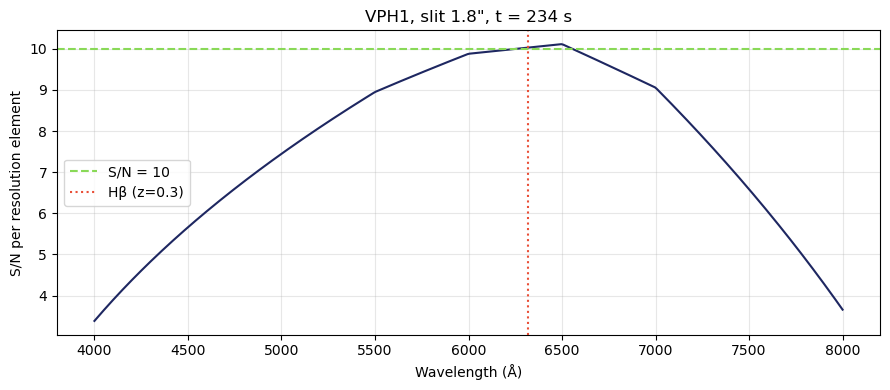

In [56]:
# Plot S/N vs wavelength at the solved exposure
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(r.wavelength_aa, r.snr_per_resel, color="#1E2761")
ax.axhline(10, color="#89D957", linestyle="--", label="S/N = 10")
ax.axvline(6320, color="#E94F37", linestyle=":", label="Hβ (z=0.3)")
ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("S/N per resolution element")
ax.set_title(f"{r.grating}, slit {r.slit_arcsec}\", t = {r.exptime_s:.0f} s")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 4. Noise budget — what each term contributes

A useful diagnostic when you write a technical justification — how much of the
noise comes from the source, the sky, and the read noise?

At λ ≈ 6316 Å, t = 1800 s, m_AB = 20:
  Source counts (N_*)  :    1801.9 e⁻
  Sky counts            :     815.1 e⁻
  Dark contribution     :       4.9 e⁻
  Read-noise variance   :     205.6 e⁻²
  S/N per res. element  :     33.89


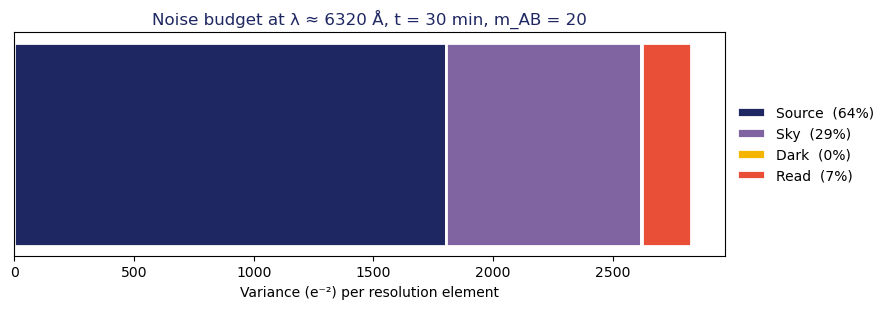

In [59]:
r = run_etc(mag_ab=20.0, grating="VPH1", slit_arcsec=1.8,
            seeing_arcsec=1.1, airmass=1.3, sky_condition="Dark",
            exptime_s=1800, n_subexp=3, extraction_height_arcsec=1.5)

# Pick the wavelength bin nearest 6320 Å
i = int(np.argmin(np.abs(r.wavelength_aa - 6320)))
print(f"At λ ≈ {r.wavelength_aa[i]:.0f} Å, t = {r.exptime_s:.0f} s, m_AB = 20:")
print(f"  Source counts (N_*)  : {r.n_star[i]:9.1f} e⁻")
print(f"  Sky counts            : {r.n_sky[i]:9.1f} e⁻")
print(f"  Dark contribution     : {r.n_dark[i]:9.1f} e⁻")
print(f"  Read-noise variance   : {r.n_read[i]:9.1f} e⁻²")
print(f"  S/N per res. element  : {r.snr_per_resel[i]:9.2f}")

# Stacked-bar noise budget (variance contributions)
fig, ax = plt.subplots(figsize=(9, 3.2))
labels = ["Source", "Sky", "Dark", "Read"]
values = [r.n_star[i], r.n_sky[i], r.n_dark[i], r.n_read[i]]
colors = ["#1E2761", "#8064A2", "#F4B400", "#E94F37"]
total = sum(values)
fracs = [v / total * 100 for v in values]
left = 0
for v, f, lab, c in zip(values, fracs, labels, colors):
    ax.barh(0, v, left=left, color=c, label=f"{lab}  ({f:.0f}%)",
            edgecolor="white", linewidth=2)
    left += v
ax.set_yticks([]); ax.set_xlabel("Variance (e⁻²) per resolution element")
ax.set_title("Noise budget at λ ≈ 6320 Å, t = 30 min, m_AB = 20", color="#1E2761")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=10, frameon=False)
plt.tight_layout(); plt.show()


## 5. System throughput curve

The ETC anchors its system efficiency to the per-component throughput model
(telescope mirrors + focal-reducer L1 + LRS internals + BEX2-DD QE).
Replace `EFF_TOTAL` with the official curve as soon as you have it.

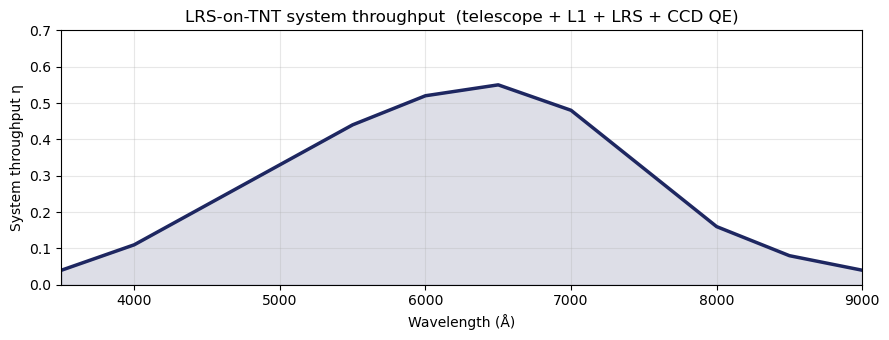

Peak η = 0.55 at λ = 6500 Å
Mean η over 4000-8000 Å = 0.37


In [62]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(WAV_GRID_AA, EFF_TOTAL, color="#1E2761", lw=2.5)
ax.fill_between(WAV_GRID_AA, EFF_TOTAL, alpha=0.15, color="#1E2761")
ax.set_xlabel("Wavelength (Å)"); ax.set_ylabel("System throughput η")
ax.set_title("LRS-on-TNT system throughput  (telescope + L1 + LRS + CCD QE)")
ax.set_xlim(3500, 9000); ax.set_ylim(0, 0.7)
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"Peak η = {EFF_TOTAL.max():.2f} at λ = {WAV_GRID_AA[int(np.argmax(EFF_TOTAL))]:.0f} Å")
print(f"Mean η over 4000-8000 Å = {EFF_TOTAL[(WAV_GRID_AA>=4000)&(WAV_GRID_AA<=8000)].mean():.2f}")


## 6. M82 input spectrum (replaces user-uploaded spectrum)

The bundle ships an **M82-like input spectrum** in
`example_frames/M82_template_3500_9000.txt` (two-column ASCII: wavelength in
Å, f_λ in erg s⁻¹ cm⁻² Å⁻¹). It is anchored to the continuum level of the
reduced LRS M82 nuclear spectrum and extended with literature emission
lines + a Calzetti-attenuated stellar continuum to cover the full LRS
wavelength range. Use it whenever you want a realistic SED for the ETC.

Loaded M82 template: 5501 samples, 3500-9000 Å, median f_λ = 5.93e-14 erg/s/cm²/Å


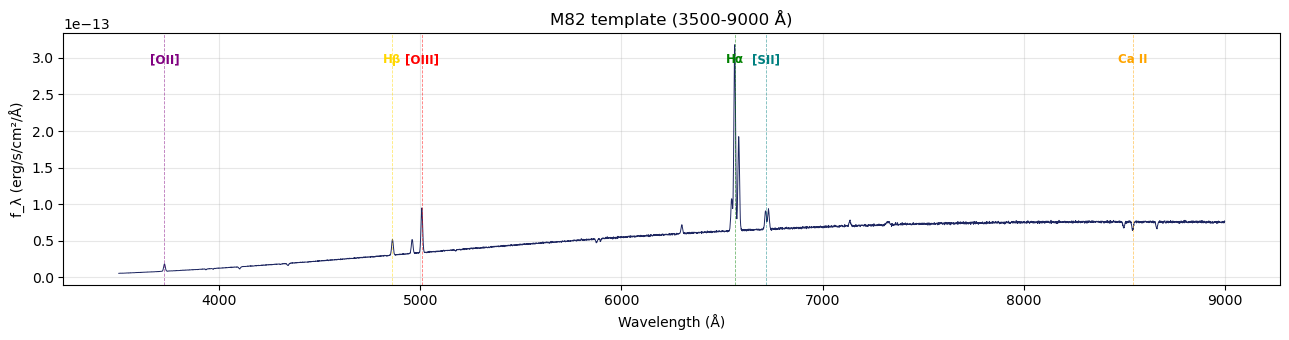

In [65]:
# Load the shipped M82 template
M82_TEMPLATE = DATA_ROOT / "M82_template_3500_9000.txt" if False else None

# Search candidates (mirrors the reduction-notebook logic)
import os
_template_candidates = [
    os.environ.get("M82_TEMPLATE"),
    os.path.expanduser("~/Documents/IF-SUT_Cosmo_School/example_frames/M82_template_3500_9000.txt"),
    "/sessions/relaxed-brave-cori/mnt/IF-SUT_Cosmo_School/example_frames/M82_template_3500_9000.txt",
    "./example_frames/M82_template_3500_9000.txt",
    "./M82_template_3500_9000.txt",
]
M82_TEMPLATE_PATH = None
for c in _template_candidates:
    if c and os.path.isfile(c):
        M82_TEMPLATE_PATH = c; break
if M82_TEMPLATE_PATH is None:
    raise FileNotFoundError("Could not locate M82_template_3500_9000.txt")

_arr = np.loadtxt(M82_TEMPLATE_PATH)
M82_SPECTRUM = dict(wavelength_aa=_arr[:, 0], flam=_arr[:, 1])
print(f"Loaded M82 template: {len(_arr)} samples, "
      f"{_arr[:,0].min():.0f}-{_arr[:,0].max():.0f} Å, "
      f"median f_λ = {np.median(_arr[:,1]):.2e} erg/s/cm²/Å")

# Visualise it next to a few key lines
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(_arr[:, 0], _arr[:, 1], color="#1E2761", lw=0.7)
for lam, lbl, col in [(3727, "[OII]", "purple"), (4861, "Hβ", "gold"),
                      (5007, "[OIII]", "red"), (6563, "Hα", "green"),
                      (6717, "[SII]", "teal"), (8542, "Ca II", "orange")]:
    ax.axvline(lam, color=col, lw=0.6, ls="--", alpha=0.55)
    ax.text(lam, _arr[:, 1].max() * 0.92, lbl, ha="center", color=col,
            fontsize=8.5, fontweight="bold")
ax.set_xlabel("Wavelength (Å)"); ax.set_ylabel("f_λ (erg/s/cm²/Å)")
ax.set_title("M82 template (3500-9000 Å)")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 7. S/N **per pixel** as a function of (t, N)

All earlier cells reported S/N per *resolution element*. When you compare
against the LRS reduction-pipeline outputs or specify proposal exposure
plans, **S/N per pixel** is the more useful quantity.

The conversion is:

`S/N per pixel = S/N per resel  /  √(n_pix_per_resel)`

with `n_pix_per_resel = (λ/R) / dispersion_per_pixel` along the dispersion
axis. For LRS the resel is ≈ 4 Å wide and the dispersion is 4 Å/pixel, so
`n_pix_per_resel ≈ 1` — the per-pixel S/N is essentially the same as the
per-resel S/N. For finer-dispersion modes the factor matters.

In [68]:
def snr_per_pixel(t_per_frame, n_frames,
                  spectrum=None,
                  mag_ab=None,
                  grating="VPH1",
                  slit_arcsec=1.8,
                  seeing_arcsec=1.1,
                  airmass=1.3,
                  sky_condition="Dark",
                  extraction_height_arcsec=1.5,
                  use_m82_template=False):
    """
    Compute S/N **per pixel** for a stack of N frames of t-second exposures.

    Returns
    -------
    wav : ndarray (Å)
    snr : ndarray, S/N per pixel
    info : dict with the result object and the per-pixel contributions.

    Either supply a spectrum dict ({'wavelength_aa', 'flam'}), set
    use_m82_template=True (uses the M82 template loaded above), or supply
    mag_ab for a flat AB-magnitude source.
    """
    if use_m82_template:
        spectrum = M82_SPECTRUM
    if spectrum is None and mag_ab is None:
        mag_ab = 20.0          # sensible default

    total_t = t_per_frame * n_frames
    r = run_etc(
        mag_ab=mag_ab if spectrum is None else 0.0,
        spectrum=spectrum,
        grating=grating,
        slit_arcsec=slit_arcsec,
        seeing_arcsec=seeing_arcsec,
        airmass=airmass,
        sky_condition=sky_condition,
        exptime_s=total_t,
        n_subexp=n_frames,
        extraction_height_arcsec=extraction_height_arcsec,
    )

    # Pixels per resolution element for this grating + dispersion
    g = GRATINGS[grating]
    delta_lambda_resel = r.wavelength_aa / g["R"]
    n_pix_per_resel = np.maximum(delta_lambda_resel / g["disp_pix"], 1.0)

    # Convert from S/N per resel to S/N per pixel
    snr_pp = r.snr_per_resel / np.sqrt(n_pix_per_resel)

    return r.wavelength_aa, snr_pp, dict(result=r,
                                          n_pix_per_resel=n_pix_per_resel,
                                          total_exptime_s=total_t)


# Sanity check: M82 with a 30-min stack of 3 frames
wav, snr_pp, info = snr_per_pixel(
    t_per_frame=600, n_frames=3, use_m82_template=True,
    slit_arcsec=1.8, seeing_arcsec=1.1, sky_condition="Dark",
)
print(f"Per-pixel S/N report for M82, 3 x 600 s = 1800 s, dark sky:")
print(f"  median S/N/pix = {np.median(snr_pp):.1f}")
print(f"  peak S/N/pix   = {np.nanmax(snr_pp):.1f} at λ = {wav[int(np.nanargmax(snr_pp))]:.0f} Å")
print(f"  n_pix per resel @ λ_centre: {info['n_pix_per_resel'][len(wav)//2]:.2f}")


Per-pixel S/N report for M82, 3 x 600 s = 1800 s, dark sky:
  median S/N/pix = 1268.9
  peak S/N/pix   = 3173.5 at λ = 6566 Å
  n_pix per resel @ λ_centre: 1.56


## 8. Plot S/N per pixel vs wavelength

A one-liner helper that takes any S/N result and produces a styled plot
matching the lecture deck. Useful when comparing multiple configurations
(e.g. 1×3600 s vs 6×600 s vs 12×300 s) on the same axes.

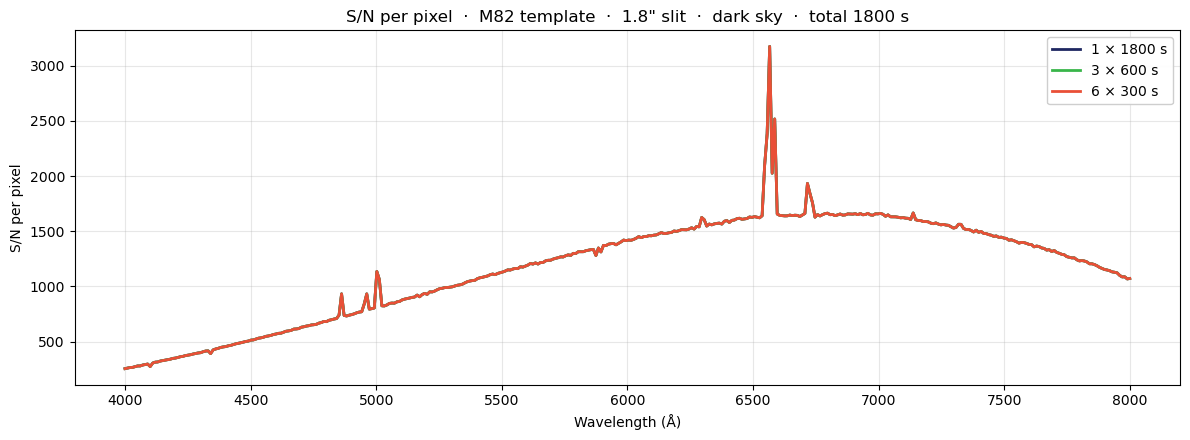

In the photon-noise regime all three should overlap (same total t·N).
Differences trace read-noise + dark contributions per pixel.


In [71]:
def plot_snr_per_pixel(wav, snr_pp, label=None, ax=None, color=None,
                       lw=1.6, **plot_kwargs):
    """Plot S/N per pixel vs wavelength. Returns the matplotlib axes."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 4.0))
        new_axes = True
    else:
        new_axes = False
    ax.plot(wav, snr_pp, color=color, lw=lw, label=label, **plot_kwargs)
    ax.set_xlabel("Wavelength (Å)")
    ax.set_ylabel("S/N per pixel")
    ax.grid(alpha=0.3)
    if new_axes:
        ax.set_title("LRS predicted S/N per pixel")
    if label is not None:
        ax.legend(loc="best", fontsize=10, framealpha=0.95)
    return ax

# Example: compare three observing strategies for M82
strategies = [
    ("1 × 1800 s",  dict(t_per_frame=1800, n_frames=1)),
    ("3 × 600 s",   dict(t_per_frame=600,  n_frames=3)),
    ("6 × 300 s",   dict(t_per_frame=300,  n_frames=6)),
]
colors = ["#1E2761", "#39B54A", "#E94F37"]

fig, ax = plt.subplots(figsize=(12, 4.5))
for (label, kw), color in zip(strategies, colors):
    wav, snr_pp, info = snr_per_pixel(use_m82_template=True,
                                       slit_arcsec=1.8,
                                       seeing_arcsec=1.1,
                                       sky_condition="Dark",
                                       **kw)
    plot_snr_per_pixel(wav, snr_pp, label=label, ax=ax, color=color, lw=2)
ax.set_title("S/N per pixel  ·  M82 template  ·  1.8\" slit  ·  dark sky  ·  total 1800 s")
plt.tight_layout(); plt.show()

print("In the photon-noise regime all three should overlap (same total t·N).")
print("Differences trace read-noise + dark contributions per pixel.")


## 9. Quick lookup — `solve_t_per_frame_for_snr_pp()`

Given a target S/N per pixel at a specific wavelength and the number of
sub-exposures you want, return the exposure time per frame.

In [74]:
def solve_t_per_frame_for_snr_pp(target_snr_pp, n_frames,
                                  line_wavelength_aa,
                                  **kwargs):
    """Bisect on t_per_frame to hit a target S/N per pixel at λ."""
    def snr_at_t(tpf):
        wav, snr_pp, _ = snr_per_pixel(t_per_frame=tpf, n_frames=n_frames, **kwargs)
        i = int(np.argmin(np.abs(wav - line_wavelength_aa)))
        return snr_pp[i]

    lo, hi = 5.0, 36000.0   # 5 s … 10 hr
    if snr_at_t(hi) < target_snr_pp:
        print(f"⚠ Even {hi:.0f} s/frame x {n_frames} gives only "
              f"S/N/pix = {snr_at_t(hi):.1f}")
        return hi
    if snr_at_t(lo) > target_snr_pp:
        return lo
    for _ in range(40):
        mid = 0.5 * (lo + hi)
        if snr_at_t(mid) < target_snr_pp:
            lo = mid
        else:
            hi = mid
        if hi - lo < 1.0: break
    return 0.5 * (lo + hi)


# Example: aim for S/N/pix = 25 at Hα for the M82 template with N=3 frames
t_needed = solve_t_per_frame_for_snr_pp(
    target_snr_pp=25, n_frames=3,
    line_wavelength_aa=6563,
    use_m82_template=True,
    slit_arcsec=1.8, seeing_arcsec=1.1, sky_condition="Dark",
)
print(f"For S/N/pix = 25 at Hα, M82 template, 3 frames, dark sky, 1.8\" slit:")
print(f"  exposure per frame = {t_needed:.0f} s   "
      f"(total {3*t_needed:.0f} s = {3*t_needed/60:.1f} min)")


For S/N/pix = 25 at Hα, M82 template, 3 frames, dark sky, 1.8" slit:
  exposure per frame = 5 s   (total 15 s = 0.2 min)


## 10. Redshifting the M82 template — higher-z galaxies

How does the same starburst look through LRS if we move M82 to z = 0.05,
0.1, 0.2, or 0.5? Two effects to apply:

1. **Wavelength shift** — every rest-frame line moves to `λ_obs = λ_rest (1 + z)`.
2. **Cosmological dimming** — the observed flux scales as

       f_λ(obs)  =  f_λ(rest)  /  (1 + z)  ·  (D_L,M82 / D_L(z))²

   where `D_L` is the luminosity distance. We use `astropy.cosmology` if
   available, otherwise a flat-ΛCDM short-cut (H₀ = 70 km/s/Mpc, Ω_m = 0.3).

The M82 reference distance is **D_L ≈ 3.5 Mpc** (Karachentsev+ 2002).
At z = 0.05 the same galaxy is ~14000× fainter (≈ +9.5 mag), so the same
30-minute exposure won't get the same per-pixel S/N — we'll see how the
S/N actually scales.

In [77]:
# --- Cosmology helper -------------------------------------------------
M82_DLUM_MPC = 3.5     # Karachentsev et al. 2002 (TRGB distance)

try:
    from astropy.cosmology import FlatLambdaCDM
    from astropy import units as u
    _cosmo = FlatLambdaCDM(H0=70, Om0=0.30)
    def luminosity_distance_Mpc(z):
        return float(_cosmo.luminosity_distance(z).to(u.Mpc).value)
except Exception:
    # Fallback: integrate flat-ΛCDM by hand
    def luminosity_distance_Mpc(z, H0=70.0, Om=0.30):
        c_km = 2.998e5
        DH = c_km / H0                                       # Mpc
        def E(zp): return (Om * (1 + zp)**3 + (1 - Om))**0.5
        if z == 0: return 0.0
        zs = np.linspace(0, z, 1024); dz = zs[1] - zs[0]
        DC = DH * np.trapz(1.0 / E(zs), dx=dz)               # comoving
        return DC * (1 + z)

def redshift_spectrum(spectrum, z, d_L_local_Mpc=M82_DLUM_MPC):
    """Shift a rest-frame spectrum to redshift z with cosmological dimming.

    Parameters
    ----------
    spectrum : dict with 'wavelength_aa' (rest-frame Å) and 'flam' (erg/s/cm²/Å)
    z        : target redshift
    d_L_local_Mpc : luminosity distance of the local (z≈0) template

    Returns
    -------
    spectrum_z : dict with redshifted 'wavelength_aa' and 'flam'
    """
    wav_rest, flam_rest = spectrum["wavelength_aa"], spectrum["flam"]
    wav_obs = wav_rest * (1 + z)
    if z <= 0:
        return dict(wavelength_aa=wav_obs, flam=flam_rest,
                    z=z, d_L_Mpc=d_L_local_Mpc, dim_factor=1.0)
    DL_z = luminosity_distance_Mpc(z)
    dim_factor = (d_L_local_Mpc / DL_z) ** 2 / (1 + z)
    flam_obs = flam_rest * dim_factor
    return dict(wavelength_aa=wav_obs, flam=flam_obs,
                z=z, d_L_Mpc=DL_z, dim_factor=dim_factor)


# Verify on a small range of z
print(f"{'z':>6}  {'D_L (Mpc)':>11}  {'dim factor':>11}  {'Δmag':>6}")
print("-" * 42)
for z in [0.0, 0.01, 0.05, 0.10, 0.20, 0.50]:
    DL = luminosity_distance_Mpc(z) if z > 0 else M82_DLUM_MPC
    dim = (M82_DLUM_MPC / DL) ** 2 / (1 + z) if z > 0 else 1.0
    dmag = -2.5 * np.log10(dim) if dim > 0 else float("inf")
    print(f"  {z:>4.2f}   {DL:11.1f}   {dim:11.2e}   {dmag:+5.1f}")


     z    D_L (Mpc)   dim factor    Δmag
------------------------------------------
  0.00           3.5      1.00e+00    -0.0
  0.01          43.2      6.51e-03    +5.5
  0.05         222.3      2.36e-04    +9.1
  0.10         460.3      5.26e-05   +10.7
  0.20         980.1      1.06e-05   +12.4
  0.50        2832.9      1.02e-06   +15.0


## 11. ETC predictions at z = 0, 0.05, 0.1, 0.2, 0.5

Apply the redshifter, then run `snr_per_pixel()` on each redshifted
spectrum with the same 3 × 600 s exposure plan. Plot S/N/pixel vs observed
wavelength so each redshift's emission-line positions are visible.

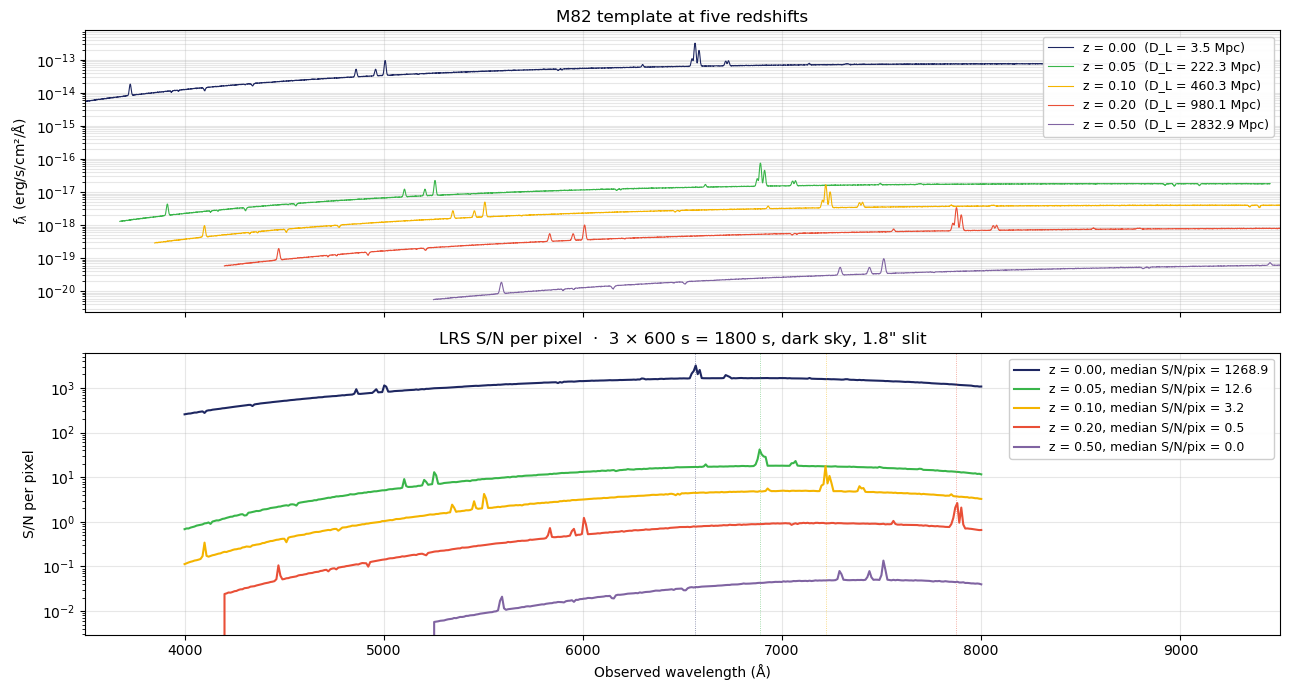


    z    D_L (Mpc)    med S/N/pix    peak S/N/pix
-----------------------------------------------------
  0.00           3.5          1268.9           3173.5
  0.05         222.3            12.6             41.8
  0.10         460.3             3.2             17.7
  0.20         980.1             0.5              2.6
  0.50        2832.9             0.0              0.1


In [80]:
z_LIST = [0.0, 0.05, 0.10, 0.20, 0.50]
COLOURS = ["#1E2761", "#39B54A", "#F4B400", "#E94F37", "#8064A2"]

fig, axs = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                        gridspec_kw=dict(height_ratios=[1, 1]))
ax_sp, ax_snr = axs

summary = []
for z, col in zip(z_LIST, COLOURS):
    spec_z = redshift_spectrum(M82_SPECTRUM, z)
    ax_sp.plot(spec_z["wavelength_aa"], spec_z["flam"], color=col, lw=0.8,
               label=f"z = {z:.2f}  (D_L = {spec_z['d_L_Mpc']:.1f} Mpc)")
    wav, snr_pp, info = snr_per_pixel(
        t_per_frame=600, n_frames=3,
        spectrum=spec_z,
        grating="VPH1",
        slit_arcsec=1.8, seeing_arcsec=1.1, sky_condition="Dark",
    )
    ax_snr.plot(wav, snr_pp, color=col, lw=1.5,
                label=f"z = {z:.2f}, median S/N/pix = {np.nanmedian(snr_pp):.1f}")
    # Mark the observed Hα for each z
    Halpha_obs = 6563 * (1 + z)
    if 4000 < Halpha_obs < 8000:
        ax_snr.axvline(Halpha_obs, color=col, lw=0.6, ls=":", alpha=0.6)
    summary.append((z, spec_z["d_L_Mpc"],
                    np.nanmedian(snr_pp),
                    np.nanmax(snr_pp[np.isfinite(snr_pp)])))

ax_sp.set_yscale("log")
ax_sp.set_ylabel(r"$f_\lambda$ (erg/s/cm²/Å)")
ax_sp.set_title("M82 template at five redshifts")
ax_sp.legend(loc="upper right", fontsize=9, framealpha=0.95)
ax_sp.set_xlim(3500, 9500); ax_sp.grid(alpha=0.3, which="both")

ax_snr.set_xlabel("Observed wavelength (Å)")
ax_snr.set_ylabel("S/N per pixel")
ax_snr.set_title("LRS S/N per pixel  ·  3 × 600 s = 1800 s, dark sky, 1.8\" slit")
ax_snr.legend(loc="upper right", fontsize=9, framealpha=0.95)
ax_snr.set_xlim(3500, 9500); ax_snr.grid(alpha=0.3)
ax_snr.set_yscale("log")

plt.tight_layout(); plt.show()

print(f"\n{'z':>5}  {'D_L (Mpc)':>11}  {'med S/N/pix':>13}  {'peak S/N/pix':>14}")
print("-" * 53)
for z, DL, med, pk in summary:
    print(f"  {z:.2f}   {DL:11.1f}   {med:13.1f}   {pk:14.1f}")


## 11b. Exposure to keep S/N at Hα = 10 per pixel vs z

If we want to deliver **S/N per pixel = 10 at the (redshifted) Hα line**,
how long do we need? Sweeping z makes the limiting effect of cosmological
dimming and Hα leaving the LRS band (above z ≈ 0.22) visible.

    z    λ_obs(Hα)    D_L (Mpc)    t/frame (s)          total
-----------------------------------------------------------------
  0.00        6563.0           3.5               5        0.2 min
  0.02        6694.3          87.0               6        0.3 min
  0.05        6891.2         222.3              51        2.6 min
  0.08        7088.0         363.3             116        5.8 min
  0.10        7219.3         460.3             229       11.5 min
  0.15        7547.4         713.2             974       48.7 min
  0.20        7875.6         980.1            5659      282.9 min


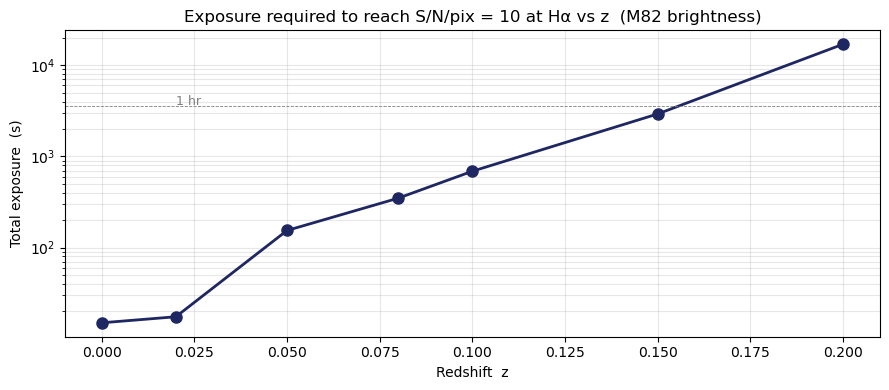


Note: above z ≈ 0.22 the observed Hα drops out of the LRS band (7400 Å > 8000 Å limit), so the table reports nan.


In [83]:
z_grid = np.array([0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20])
times = []
for z in z_grid:
    Hα_obs = 6563.0 * (1 + z)
    if Hα_obs < 4000 or Hα_obs > 8000:
        times.append(np.nan); continue
    spec_z = redshift_spectrum(M82_SPECTRUM, z)
    t = solve_t_per_frame_for_snr_pp(
        target_snr_pp=10, n_frames=3,
        line_wavelength_aa=Hα_obs,
        spectrum=spec_z,
        grating="VPH1",
        slit_arcsec=1.8, seeing_arcsec=1.1, sky_condition="Dark",
    )
    times.append(t)
times = np.array(times)

print(f"{'z':>5}  {'λ_obs(Hα)':>11}  {'D_L (Mpc)':>11}  {'t/frame (s)':>13}  "
      f"{'total':>13}")
print("-" * 65)
for z, t in zip(z_grid, times):
    Hα = 6563.0 * (1 + z); DL = luminosity_distance_Mpc(z) if z > 0 else M82_DLUM_MPC
    total = 3 * t if np.isfinite(t) else np.nan
    total_str = f"{total/60:6.1f} min" if np.isfinite(total) else "—"
    print(f"  {z:.2f}   {Hα:11.1f}   {DL:11.1f}   {t:13.0f}  {total_str:>13}")

fig, ax = plt.subplots(figsize=(9, 4))
ok = np.isfinite(times)
ax.plot(z_grid[ok], times[ok] * 3, "o-", color="#1E2761", lw=2, ms=8,
        label="total on-source for S/N=10 at Hα")
ax.set_yscale("log")
ax.set_xlabel("Redshift  z")
ax.set_ylabel("Total exposure  (s)")
ax.set_title("Exposure required to reach S/N/pix = 10 at Hα vs z  (M82 brightness)")
ax.grid(alpha=0.3, which="both")
ax.axhline(3600, color="gray", lw=0.6, ls="--")
ax.text(0.02, 3700, "1 hr", color="gray", fontsize=9)
plt.tight_layout(); plt.show()

print("\nNote: above z ≈ 0.22 the observed Hα drops out of the LRS band "
      "(7400 Å > 8000 Å limit), so the table reports nan.")


---

### Student tasks

1. Swap `slit_arcsec=1.8` for the 2.7″ slit and re-run the noise budget. How
   much does the S/N change?
2. Replace `use_m82_template=True` with `spectrum=M82_SPECTRUM` but apply your
   own scaling (e.g. multiply `flam` by 0.1 to simulate a 2.5-mag-fainter
   target). Confirm the per-pixel S/N drops by √10.
3. Use `solve_t_per_frame_for_snr_pp` to find the per-frame exposure that
   delivers S/N/pix = 10 at the [O III] 5007 line for the M82 template, for
   N = 5 frames, dark sky.
4. Plot the noise budget at the [O III] wavelength and compare to the budget
   at Hα. Where is the regime sky-limited vs read-noise-limited?

---

*Built for the IF-SUT Cosmo School short course "Spectroscopic Capabilities
in Thailand for Extragalactic Astronomy".*
